In [84]:
import pandas as pd
from src.utils import hot_encode_sequence, create_path
import torch
from fastprogress import progress_bar
from src.config import ExpressionConfig
from src.utils import read_json, get_device
from src.DeepPlant_expression import build_model
import numpy as np
from src.ISM_utils import *
import os
from dotenv import load_dotenv
import h5py

# 1. Load the variables from the .env file
load_dotenv()

# 2. Grab the global path
deep_plant_path = os.getenv("DEEPPLANTPATH")

if not deep_plant_path:
    raise ValueError("DEEPPLANTPATH is missing! Run 'pip install -e' in the root DeepPlant directory")

# Build model and import data

In [85]:
device = get_device()
json_path = os.path.join(deep_plant_path,"config/config_AT_expression.json")
GEP_model_path = os.path.join(deep_plant_path,"models/model_AT_GEP.pt")
gene_df_path = os.path.join(deep_plant_path,"data/arabidopsis/GEP/arabidopsis_expression_data.csv")
GEP_metadata_path = os.path.join(deep_plant_path,"data/arabidopsis/GEP/exp_label.txt")
bed_files_path = os.path.join(deep_plant_path,"data/arabidopsis/bed")
CSP_metadata_path = os.path.join(deep_plant_path,"data/arabidopsis/CSP/AT_CSP_Metadata.csv")
Jaspar_meme_path = os.path.join(deep_plant_path,"data/arabidopsis/jaspar/all.meme")
H5_file_path = os.path.join(deep_plant_path,"data/arabidopsis/GEP/expression_data_TSS.h5")

config = ExpressionConfig(**read_json(json_path=json_path))
model = build_model(args=config,new_model=False,model_path=GEP_model_path).to(device)
gene_df = pd.read_csv(gene_df_path)
gex_metadata = pd.read_csv(GEP_metadata_path,sep='\t')
csp_metadata = pd.read_csv(CSP_metadata_path)
motifs_dict = load_meme_database(meme_path=Jaspar_meme_path)
motifs_dict = get_latest_motifs(motifs_dict)
back_freq = nuclt_dict(gene_df.sequence.values.tolist()) #{"A": 0.25, "C": 0.25, "G": 0.25, "T": 0.25}
pssm_dict_jaspar = get_motifs(motifs_dict, back_freq)
h5_gex = h5py.File(H5_file_path)

Loading model state
Model state loaded


# Select a gene of interest for analysis.
# Below is a list of recommended genes with well-characterized regulatory behavior.

| Gene | Gene name | Stress Induced |
| :--- | :--- | :--- |
| AT5G52310 | RAD29A | General Stress
| AT4G25470 | CBF2 / DREB1C | Cold
| AT4G25480 | CBF3 / DREB1A | Cold
| AT4G25490 | CBF1 / DREB1B | Cold
| AT5G59820 | ZAT12 | Cold
| AT2G42540 | COR15A | Cold
| AT3G63480 | KIN1 | Cold
| AT5G15970 | KIN2 | Cold 
| AT1G20450 | ERD10 | Cold + drought/dehydration + ABA
| AT5G05410 | DREB2A | Heat + drought/Dehydration
| AT3G02990 | HSFA1E | Heat
| AT1G16030 | HSP7E | Heat
| AT1G54160 | NFYA5 | Drought/Dehydration
| AT1G29920 | LHCB1 | Light
| AT3G15540 | IAA19 | Auxin
| AT2G01980 | SOS1 | Salinity

In [88]:
gene = "AT5G52310"
gene_df.loc[gene_df.gene==gene]

,header,sequence,gene,tss,chrom,strand
31476,AT5G52310_5_21240717,ATGTATTTTATCTTTGTGTGAAAAAGAGATTGGGTTAATAAAATAT...,AT5G52310,21240717,5,1


In [89]:
header = gene_df.loc[gene_df.gene==gene].header.values[0].__str__()
sequence = gene_df.loc[gene_df.gene==gene].sequence.values[0].__str__()
strand = gene_df.loc[gene_df.gene==gene].strand.values[0].__str__()
tss = gene_df.loc[gene_df.gene==gene].tss.values[0].__str__()
chrom = gene_df.loc[gene_df.gene==gene].chrom.values[0].__str__()
gene_idx = gene_df.loc[gene_df.gene==gene].index.values[0]
gene_output = h5_gex['labels'][gene_idx]
gene_results_path = os.path.join(deep_plant_path,f"results/ISM/{gene}")
create_path(gene_results_path)
nuclt = ["A", "C", "G", "T"]
sum_lfc = torch.zeros(4, 2500, 3142).to(device)
ref_allele = sequence
eps = 0.1 # for stability
ref_input = torch.from_numpy(hot_encode_sequence(sequence=ref_allele, length_after_padding=2500)).unsqueeze(0).to(device)
with torch.no_grad():
    model.eval()
    ref_labels = model(input=ref_input)
    for idx in progress_bar(range(len(ref_allele))):
        for j, nucl in enumerate(nuclt):
            if ref_allele[idx] != nucl:
                mut_allele = ref_allele[:idx] + nucl + ref_allele[idx + 1 :]
                mut_input = (
                    torch.tensor(
                        hot_encode_sequence(mut_allele), dtype=torch.float
                    )
                    .unsqueeze(0)
                    .to(device)
                )
                mut_label = model(input=mut_input)
                sum_lfc[j, idx] = (torch.log(mut_label + eps) - torch.log(ref_labels + eps))
sum_lfc = sum_lfc.cpu().numpy()

# Select the experiment or treatment of interest by setting `exp_id`.
# Below is a list of experiment IDs corresponding to RNA-seq studies under various stress conditions.

| Condition | exp_ids |
| :--- | :--- |
| Cold 1 hour | 279 |
| Cold 3 hours | 282 |
| Cold 6 hours | 283 |
| Cold 12 hours | 280 |
| Cold 24 hours | 281 |
| Heat 1 hour | 284 |
| Heat 12 hours | 285 |
| Heat 24 hours | 286 |
| Wounding 1 hour | 287 |
| Wounding 12 hours | 288 |
| Wounding 24 hours | 289 |
| Short-term drought | 2504 |
| Long-term drought | 2503 |
| Salinity | 2280-2808 |
| Nitrogen, Cycloheximide, Dexamethasone | 2494 |
| ABA 1 hour | 1309 |
| ABA 3 hours | 1310 |
| Auxin 55 hours | 1531 |
| Injury+Auxin 55 hours | 1529 |

In [92]:
exp_id = 2504
print(gex_metadata.iloc[exp_id])
print(f"Gene {gene} expression is {gene_output[exp_id]}" )

Sample                       SRX4508528
SampleName                       WT_LD2
Tissue                           leaves
Ecotype                           Col-0
Genotype                      Wild type
Treatment            short-term drought
Project                     PRJNA484081
TotalReads                     22080931
UniqueMappedRatio                0.9006
ReleaseDate                    2019/9/2
Name: 2504, dtype: object
Gene AT5G52310 expression is 94.197509765625


Most important positions are  [1159 1160 1161 1162 1163 1215 1216 1217 1218 1219 1220 1221 1256 1264
 1266 1281 1318 1319 1320 1321 1322 1324 1452]
Analysing mutations positions for TF enrichment


Refer to the csv file at /s/chromatin/m/nobackup/ahmed/GitRepositries/DeepPlant/results/ISM/AT5G52310/results_short-term drought.csv to see all mutations positions and TF enrichments
Successfully created Zoom_in.bed at: /s/chromatin/m/nobackup/ahmed/GitRepositries/DeepPlant/results/pygenometracks/Zoom_in.bed
Successfully created track.ini at: /s/chromatin/m/nobackup/ahmed/GitRepositries/DeepPlant/results/pygenometracks/track.ini
A mutation at position 1159 relative to the sequence, C -> G causes the loss of the binding site of ['MA0971.2.DREB1A', 'MA1218.2.DREB1D', 'MA1669.2.DREB1B', 'MA1670.2.DREB1C']
A mutation at position 1160 relative to the sequence, C -> A causes the loss of the binding site of ['MA0971.2.DREB1A', 'MA1218.2.DREB1D', 'MA1669.2.DREB1B', 'MA1670.2.DREB1C']
A mutation at position 1161 relative to the sequence, G -> A causes the loss of the binding site of ['MA0971.2.DREB1A', 'MA1218.2.DREB1D', 'MA1669.2.DREB1B', 'MA1670.2.DREB1C']
A mutation at position 1162 relative

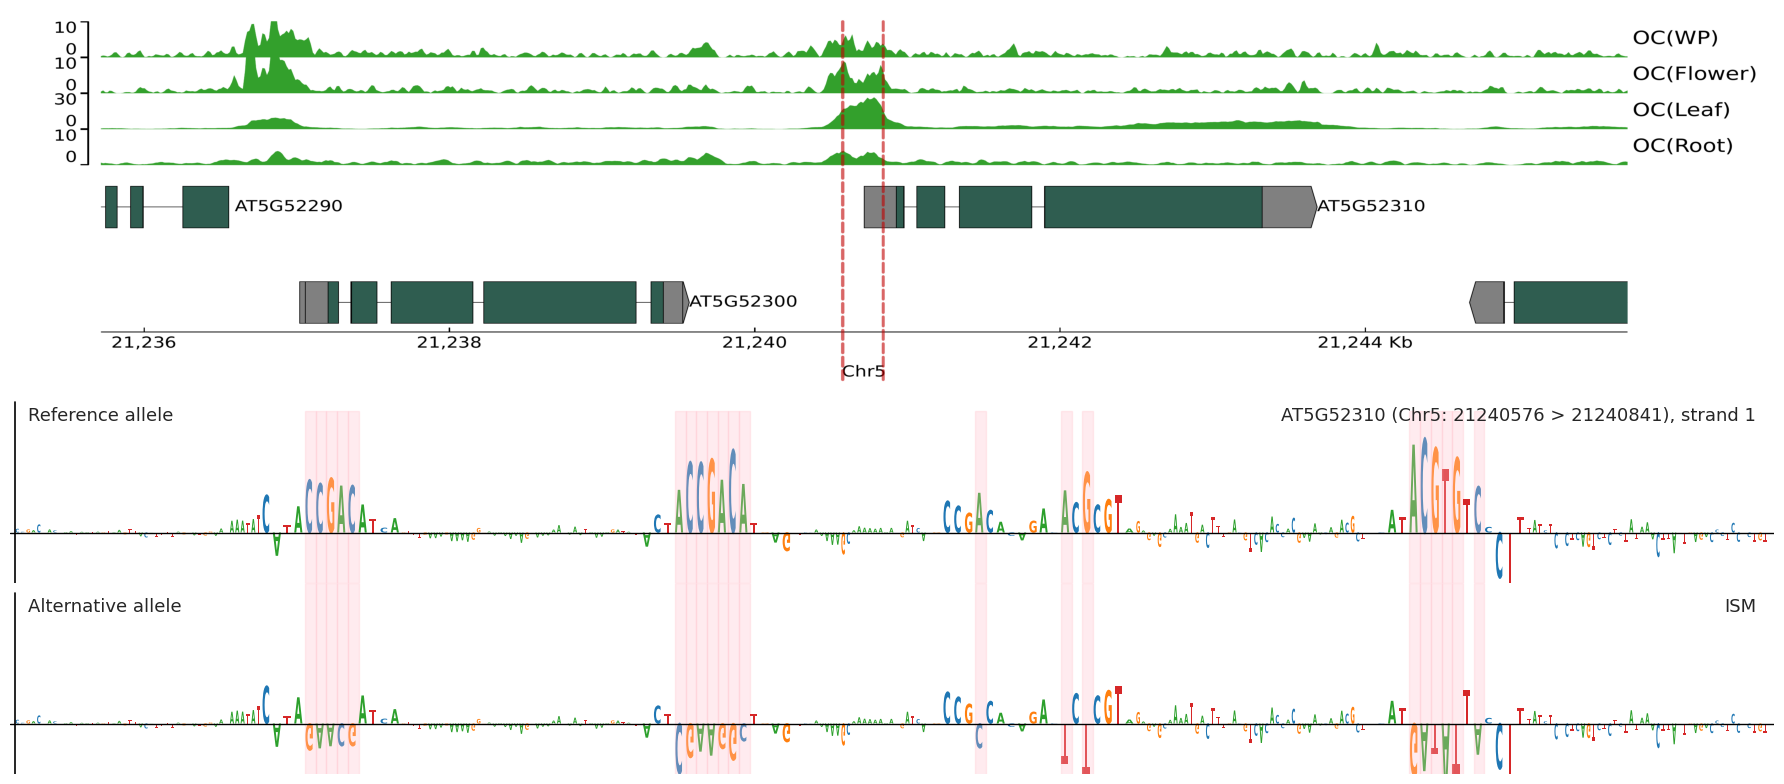

In [94]:
treatment = gex_metadata.iloc[exp_id].Treatment
ISM_values = ((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)
Imporatant_positions = np.where(ISM_values>0.4*ISM_values.max())[0]
print('Most important positions are ',Imporatant_positions)
print('Analysing mutations positions for TF enrichment')
results_df = analyze_mutations_with_chip(
    gene=gene,
    sum_lfc=sum_lfc[:,:,exp_id],
    ref_sequence=ref_allele,
    nuclt=nuclt,
    gene_df_full=gene_df,
    motif_dict=pssm_dict_jaspar,
    metadata=csp_metadata,
    bed_files_path=bed_files_path,
    mutation_threshold=0.4,
    score_threshold=0.7,
    pad=20
)
csv_file_path = f"{gene_results_path}/results_{treatment}.csv"
results_df.to_csv(csv_file_path,index=False)
print(f"Refer to the csv file at {csv_file_path} to see all mutations positions and TF enrichments")
loss_df = results_df.loc[
    (results_df.chip_peak_overlap == True) &
    (results_df.effect == 'Loss')
]
start = min(loss_df.relative_position.values.tolist())-50
end = max(loss_df.relative_position.values.tolist())+50
mutations_bed_path = create_zoom_in_bed(deep_plant_path,chrom,relative_to_genomic_position(start,tss,strand),relative_to_genomic_position(end,tss,strand))
ini_file_path = create_track_ini(deep_plant_path, mutations_bed_path)
target_chromosome = f"Chr{chrom}"
start_pos = int(tss)-5000
end_pos = int(tss)+5000
output_name = f"deep_plant_pathtrack__{gene}.pdf"
figure_path = os.path.join(deep_plant_path,f"results/pygenometracks/{output_name}")
!pyGenomeTracks --tracks {ini_file_path} --region {target_chromosome}:{start_pos}-{end_pos} --outFileName {figure_path} --dpi 500 --trackLabelFraction 0.0 > /dev/null 2>&1

plot_ref_alt_ism(
    figure_path=figure_path,
    gene=gene,
    chrom=f"Chr{chrom}",
    sum_lfc=sum_lfc[:,:,exp_id],
    ref_sequence=ref_allele,
    results_df=loss_df,
    start = min(loss_df.relative_position.values.tolist())-50,
    end = max(loss_df.relative_position.values.tolist())+50,
    tss=tss,
    strand=strand
)
